# Character Recognition CNN - EMNIST `byclass`

A small convolutional classifier trained on [EMNIST](https://www.nist.gov/itl/products-and-services/emnist-dataset) `byclass` (62 classes: 0-9, A-Z, a-z, case-sensitive) with hyperparameter tuning via [Optuna](https://optuna.org/).

This is Stage 1 - Recognition. Upstream:
- Stage 1 - Denoising: [../denoising/train_denoising_autoencoder.ipynb](../denoising/train_denoising_autoencoder.ipynb)
- Stage 1 - Segmentation: [../segmentation/segment_characters.py](../segmentation/segment_characters.py)

The weights produced by this notebook are saved to `../models/recognition_cnn.pt` alongside the denoising autoencoder's weights and are intended to be loaded by `../main.py` at inference time.

The notebook:

1. Loads EMNIST `byclass` via `torchvision`.
2. Applies the EMNIST-specific transpose fix + standard normalization.
3. Defines a small, parameterizable CNN so Optuna can tune model capacity.
4. Runs an Optuna search (short inner training runs, median pruning) over learning rate, optimizer, dropout, conv widths, and the FC hidden dim.
5. Retrains the best configuration for the full number of epochs.
6. Evaluates on the held-out test set with accuracy, a `classification_report`, a confusion matrix, and a qualitative prediction grid.
7. Saves the best weights together with the winning hyperparameters.

In [2]:
import copy
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import transforms
from torchvision.datasets import EMNIST
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import optuna
from optuna.pruners import MedianPruner
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Device selection

Use Apple's Metal Performance Shaders backend when available, then CUDA, then CPU.

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


## Paths

All paths are resolved relative to this notebook's folder so the notebook works regardless of the kernel's CWD.

- `DATA_DIR` caches the EMNIST download locally under `recognition/data/`. This folder is already covered by the repo's root `.gitignore` (`data/`).
- `MODELS_DIR` is shared with the denoising stage so all trained weights live in one place.

In [4]:
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR / "data"
MODELS_DIR = NOTEBOOK_DIR.parent / "models"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR  :", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)

DATA_DIR  : /Users/suryaguthikonda/Personal/Github/crisp/stage1_ocr/recognition/data
MODELS_DIR: /Users/suryaguthikonda/Personal/Github/crisp/stage1_ocr/models


## Label map

EMNIST `byclass` has 62 classes in the order `0-9`, `A-Z`, `a-z`. `LABEL_MAP[i]` gives the printable character for class index `i`.

In [5]:
NUM_CLASSES = 62
LABEL_MAP = (
    [str(d) for d in range(10)]
    + [chr(ord("A") + i) for i in range(26)]
    + [chr(ord("a") + i) for i in range(26)]
)
assert len(LABEL_MAP) == NUM_CLASSES

print("First 15 classes :", LABEL_MAP[:15])
print("Last  15 classes :", LABEL_MAP[-15:])

First 15 classes : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E']
Last  15 classes : ['l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## Preprocessing

EMNIST images are stored rotated 90 degrees clockwise and flipped horizontally relative to the "upright" orientation humans read. The classic fix is `Image.TRANSPOSE` (equivalent to rotate 90 CCW then mirror), applied before anything else.

`build_transforms(augment=...)` is the single source of truth for the preprocessing pipeline so the same transform can be re-used at inference time from the serving code. When `augment=True` we add a small random affine jitter to help generalization.

In [6]:
IMG_SIZE = 28
EMNIST_MEAN = (0.1307,)
EMNIST_STD = (0.3081,)


def _fix_emnist_orientation(img: Image.Image) -> Image.Image:
    return img.transpose(Image.TRANSPOSE)


def build_transforms(augment: bool) -> transforms.Compose:
    steps = [transforms.Lambda(_fix_emnist_orientation)]
    if augment:
        steps.append(
            transforms.RandomAffine(
                degrees=10, translate=(0.08, 0.08), scale=(0.9, 1.1), fill=0
            )
        )
    steps.extend(
        [
            transforms.ToTensor(),
            transforms.Normalize(EMNIST_MEAN, EMNIST_STD),
        ]
    )
    return transforms.Compose(steps)


train_transform = build_transforms(augment=True)
eval_transform = build_transforms(augment=False)

## Load EMNIST

We instantiate two views of the train set - one with augmentations (for training) and one without (for validation metrics) - and index them with the same split so the validation examples are never augmented.

In [7]:
full_train_aug = EMNIST(
    root=str(DATA_DIR), split="byclass", train=True, download=True,
    transform=train_transform,
)
full_train_eval = EMNIST(
    root=str(DATA_DIR), split="byclass", train=True, download=True,
    transform=eval_transform,
)
test_set = EMNIST(
    root=str(DATA_DIR), split="byclass", train=False, download=True,
    transform=eval_transform,
)

print(f"Full train: {len(full_train_aug):,}")
print(f"Test      : {len(test_set):,}")
print(f"Classes   : {NUM_CLASSES}")

Full train: 697,932
Test      : 116,323
Classes   : 62


## Train / validation split

Carve a 10% validation set out of the official EMNIST train split with a fixed-seed generator. The official test set is kept untouched for final evaluation.

In [8]:
VAL_FRACTION = 0.1

n_total = len(full_train_aug)
n_val = int(round(n_total * VAL_FRACTION))
n_train = n_total - n_val

gen = torch.Generator().manual_seed(SEED)
train_subset_aug, val_subset_aug = random_split(
    full_train_aug, [n_train, n_val], generator=gen
)

val_subset = Subset(full_train_eval, val_subset_aug.indices)
train_subset = train_subset_aug

print(f"Train: {len(train_subset):,}")
print(f"Valid: {len(val_subset):,}")
print(f"Test : {len(test_set):,}")

Train: 628,139
Valid: 69,793
Test : 116,323


## Visualize samples

One example per class, straight from the (un-augmented) train view, labelled with the human-readable character.

/var/folders/0q/0w4kfd2j1f368l33_qspsxfr0000gn/T/ipykernel_18331/1502025523.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  train_targets = np.array(full_train_eval.targets)


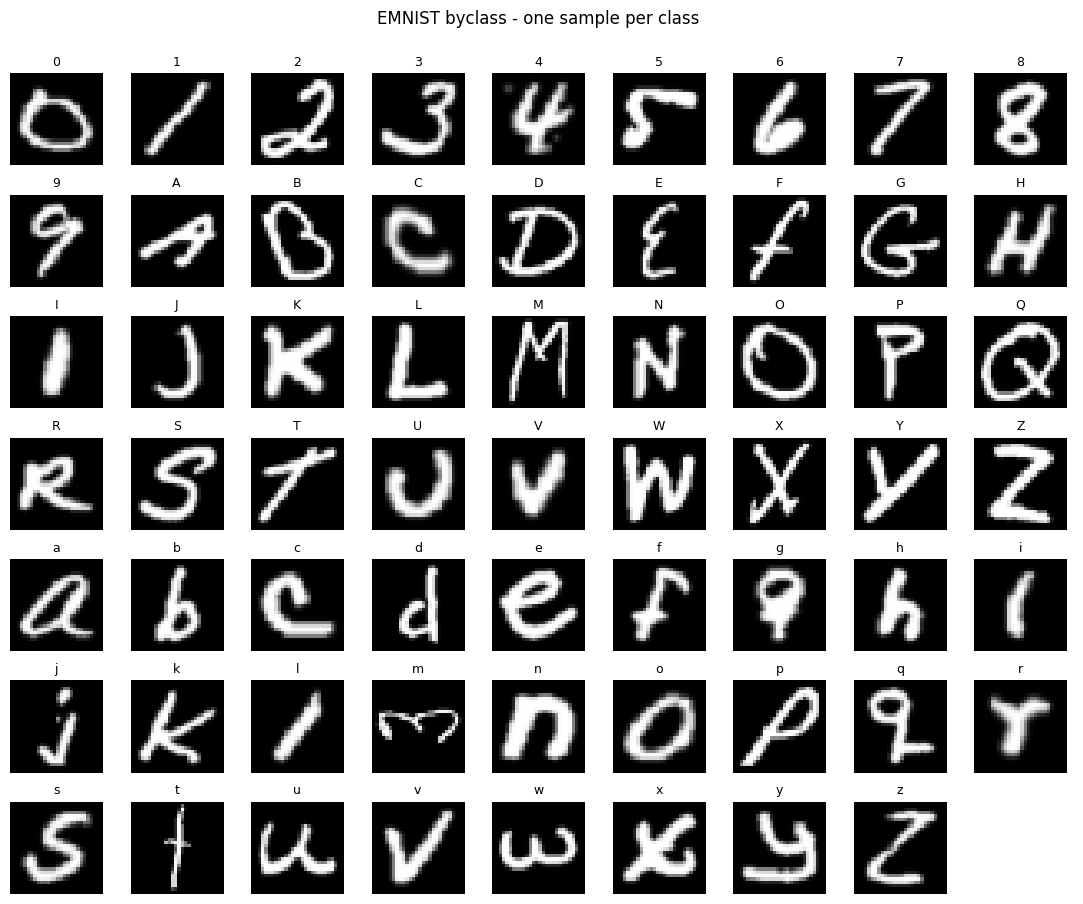

In [9]:
train_targets = np.array(full_train_eval.targets)
class_to_index: dict[int, int] = {}
for idx, y in enumerate(train_targets):
    y = int(y)
    if y not in class_to_index:
        class_to_index[y] = idx
        if len(class_to_index) == NUM_CLASSES:
            break

fig, axes = plt.subplots(7, 9, figsize=(11, 9))
axes = axes.flatten()
for cls in range(NUM_CLASSES):
    img, label = full_train_eval[class_to_index[cls]]
    axes[cls].imshow(img.squeeze().numpy(), cmap="gray")
    axes[cls].set_title(f"{LABEL_MAP[label]}", fontsize=9)
    axes[cls].axis("off")
for ax in axes[NUM_CLASSES:]:
    ax.axis("off")
plt.suptitle("EMNIST byclass - one sample per class", y=1.0)
plt.tight_layout()
plt.show()

## Class weights

EMNIST `byclass` is heavily imbalanced (digits dominate, rare-letter classes have an order of magnitude fewer samples). Compute inverse-frequency class weights from the train split and feed them to `CrossEntropyLoss` so rare classes are not ignored.

In [10]:
train_indices = np.array(train_subset_aug.indices)
train_labels = train_targets[train_indices]

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels,
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

print("Min weight:", float(class_weights.min()))
print("Max weight:", float(class_weights.max()))
print(
    "Rarest 5 classes:",
    [(LABEL_MAP[i], round(float(class_weights[i]), 2))
     for i in np.argsort(-class_weights_np)[:5]],
)

Min weight: 0.29314181208610535
Max weight: 5.897132873535156
Rarest 5 classes: [('j', 5.9), ('y', 4.8), ('k', 4.59), ('K', 4.58), ('p', 4.56)]


## CNN model

A small, parameterizable convolutional classifier - two 3x3 conv blocks (each block = 2 convs + max-pool) followed by a dropout MLP head. Keeping `conv1_ch`, `conv2_ch`, `fc_dim`, and `dropout` as constructor arguments lets Optuna tune capacity alongside the optimizer hyperparameters.

Input: `(B, 1, 28, 28)` -> 14 -> 7, then `conv2_ch * 7 * 7` features into the head.

In [11]:
class RecognitionCNN(nn.Module):
    def __init__(
        self,
        conv1_ch: int = 32,
        conv2_ch: int = 64,
        fc_dim: int = 128,
        dropout: float = 0.3,
        num_classes: int = NUM_CLASSES,
    ):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, conv1_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(conv1_ch, conv1_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(conv1_ch, conv2_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(conv2_ch, conv2_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(conv2_ch * 7 * 7, fc_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


_demo = RecognitionCNN()
_n_params = sum(p.numel() for p in _demo.parameters())
print(f"Default RecognitionCNN parameter count: {_n_params:,}")
print(_demo)

Default RecognitionCNN parameter count: 474,526
RecognitionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=3136, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=62, bias=True)
  )
)


## Training and evaluation helpers

Mirror the shape of the denoising notebook's helpers but use `CrossEntropyLoss` and track accuracy alongside loss.

In [12]:
def build_optimizer(name: str, params, lr: float) -> torch.optim.Optimizer:
    if name == "adam":
        return torch.optim.Adam(params, lr=lr)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr)
    if name == "sgd_momentum":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, nesterov=True)
    raise ValueError(f"Unknown optimizer: {name}")


def execute_trainstep(model, device, loader, loss_criterion, optimizer):
    model.train()
    losses = []
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_criterion(logits, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return float(np.mean(losses)), correct / total


@torch.no_grad()
def validate(model, device, loader, loss_criterion):
    model.eval()
    losses = []
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss = loss_criterion(logits, labels)
        losses.append(loss.item())
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return float(np.mean(losses)), correct / total


@torch.no_grad()
def evaluate_predictions(model, device, loader):
    model.eval()
    all_preds: list[np.ndarray] = []
    all_labels: list[np.ndarray] = []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)

## Hyperparameter tuning with Optuna

Search space:

| Hyperparameter | Type        | Range                         |
| -------------- | ----------- | ----------------------------- |
| `lr`           | log-uniform | 1e-4 to 1e-2                  |
| `batch_size`   | categorical | {64, 128, 256}                |
| `optimizer`    | categorical | {adam, adamw, sgd_momentum}   |
| `dropout`      | uniform     | 0.1 to 0.5                    |
| `conv1_ch`     | categorical | {16, 32, 48}                  |
| `conv2_ch`     | categorical | {32, 64, 96}                  |
| `fc_dim`      | categorical | {128, 256}                    |

To keep the search tractable on a laptop, each trial trains on a **fixed 100K-sample subset** of the train split (not the full ~627K) for `TUNING_EPOCHS` epochs, scored by validation accuracy on the unchanged validation set. The full train set is only used later for the single final retrain. Trials that look worse than the median at each epoch are pruned early with `MedianPruner`. Keep `N_TRIALS` modest so the notebook completes on a laptop.

In [13]:
N_TRIALS = 20
TUNING_EPOCHS = 3
TUNING_TRAIN_SIZE = 100_000
NUM_WORKERS = 0
PIN_MEMORY = device.type == "mps"

_tuning_rng = np.random.default_rng(SEED)
_tuning_indices = _tuning_rng.choice(
    len(train_subset), size=min(TUNING_TRAIN_SIZE, len(train_subset)), replace=False,
)
tuning_train_subset = Subset(train_subset, _tuning_indices.tolist())
print(f"Tuning train set: {len(tuning_train_subset):,} (of {len(train_subset):,})")


def make_loaders(batch_size: int, tuning: bool):
    train_src = tuning_train_subset if tuning else train_subset
    train_loader = DataLoader(
        train_src, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_subset, batch_size=512, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    return train_loader, val_loader


def objective(trial: optuna.Trial) -> float:
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    optimizer_name = trial.suggest_categorical(
        "optimizer", ["adam", "adamw", "sgd_momentum"]
    )
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    conv1_ch = trial.suggest_categorical("conv1_ch", [16, 32, 48])
    conv2_ch = trial.suggest_categorical("conv2_ch", [32, 64, 96])
    fc_dim = trial.suggest_categorical("fc_dim", [128, 256])

    model = RecognitionCNN(
        conv1_ch=conv1_ch, conv2_ch=conv2_ch, fc_dim=fc_dim, dropout=dropout,
    ).to(device)
    optimizer = build_optimizer(optimizer_name, model.parameters(), lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    train_loader, val_loader = make_loaders(batch_size, tuning=True)

    best_val_acc = 0.0
    for epoch in range(TUNING_EPOCHS):
        execute_trainstep(model, device, train_loader, criterion, optimizer)
        _, val_acc = validate(model, device, val_loader, criterion)
        best_val_acc = max(best_val_acc, val_acc)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_acc

Tuning train set: 100,000 (of 628,139)


In [14]:
sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = MedianPruner(n_warmup_steps=1)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nBest trial:")
print(f"  val_acc: {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-04-18 01:12:12,939] A new study created in memory with name: no-name-67a4c3e7-55c9-4803-ae50-81c7931a5899
  0%|          | 0/20 [00:00<?, ?it/s]/Users/suryaguthikonda/Personal/Github/crisp/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Best trial: 0. Best value: 0.744272:   5%|▌         | 1/20 [01:17<24:26, 77.18s/it]

[I 2026-04-18 01:13:30,137] Trial 0 finished with value: 0.7442723482297652 and parameters: {'lr': 0.0005611516415334506, 'batch_size': 64, 'optimizer': 'adam', 'dropout': 0.4464704583099741, 'conv1_ch': 32, 'conv2_ch': 32, 'fc_dim': 256}. Best is trial 0 with value: 0.7442723482297652.


Best trial: 1. Best value: 0.748614:  10%|█         | 2/20 [02:41<24:28, 81.56s/it]

[I 2026-04-18 01:14:54,762] Trial 1 finished with value: 0.7486137578267161 and parameters: {'lr': 0.0004059611610484307, 'batch_size': 64, 'optimizer': 'adam', 'dropout': 0.2465447373174767, 'conv1_ch': 32, 'conv2_ch': 64, 'fc_dim': 128}. Best is trial 1 with value: 0.7486137578267161.


Best trial: 1. Best value: 0.748614:  15%|█▌        | 3/20 [03:24<18:02, 63.65s/it]

...

[I 2026-04-18 04:02:47,406] Trial 17 pruned. 


Best trial: 6. Best value: 0.787987:  95%|█████████▌| 19/20 [3:34:48<42:49, 2569.47s/it]  

[I 2026-04-18 04:47:01,246] Trial 18 pruned. 


Best trial: 6. Best value: 0.787987: 100%|██████████| 20/20 [5:35:51<00:00, 1007.58s/it]

[I 2026-04-18 06:48:04,506] Trial 19 pruned. 

Best trial:
  val_acc: 0.7880
  lr: 0.0011103647313054626
  batch_size: 64
  optimizer: adamw
  dropout: 0.3034282764658811
  conv1_ch: 16
  conv2_ch: 32
  fc_dim: 128


Completed: 6, Pruned: 14


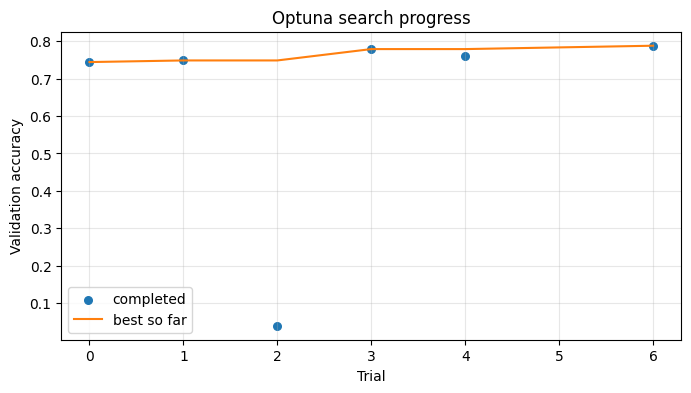

In [15]:
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
print(f"Completed: {len(completed)}, Pruned: {len(pruned)}")

plt.figure(figsize=(8, 4))
xs = [t.number for t in completed]
ys = [t.value for t in completed]
plt.scatter(xs, ys, s=30, label="completed")
if completed:
    best_so_far = np.maximum.accumulate(ys)
    plt.plot(xs, best_so_far, color="tab:orange", label="best so far")
plt.xlabel("Trial")
plt.ylabel("Validation accuracy")
plt.title("Optuna search progress")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Final training

Retrain the model from scratch with the best hyperparameters for `FINAL_EPOCHS` epochs, tracking train/val loss and accuracy. Keep the best-validation-accuracy `state_dict` in memory as `best_state` for later saving.

In [16]:
FINAL_EPOCHS = 10

best_params = study.best_params
print("Retraining with:", best_params)

model = RecognitionCNN(
    conv1_ch=best_params["conv1_ch"],
    conv2_ch=best_params["conv2_ch"],
    fc_dim=best_params["fc_dim"],
    dropout=best_params["dropout"],
).to(device)
optimizer = build_optimizer(
    best_params["optimizer"], model.parameters(), best_params["lr"]
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

train_loader, val_loader = make_loaders(best_params["batch_size"], tuning=False)
test_loader = DataLoader(
    test_set, batch_size=512, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

train_losses, valid_losses = [], []
train_accs, valid_accs = [], []
best_val_acc = 0.0
best_state: dict | None = None

pbar = tqdm(range(1, FINAL_EPOCHS + 1), desc="Training")
for epoch in pbar:
    tr_loss, tr_acc = execute_trainstep(
        model, device, train_loader, criterion, optimizer
    )
    va_loss, va_acc = validate(model, device, val_loader, criterion)

    train_losses.append(tr_loss)
    valid_losses.append(va_loss)
    train_accs.append(tr_acc)
    valid_accs.append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = copy.deepcopy(model.state_dict())

    pbar.set_postfix(
        train_loss=f"{tr_loss:.4f}", val_loss=f"{va_loss:.4f}",
        train_acc=f"{tr_acc:.4f}", val_acc=f"{va_acc:.4f}",
    )

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Retraining with: {'lr': 0.0011103647313054626, 'batch_size': 64, 'optimizer': 'adamw', 'dropout': 0.3034282764658811, 'conv1_ch': 16, 'conv2_ch': 32, 'fc_dim': 128}


Training: 100%|██████████| 10/10 [21:10<00:00, 127.07s/it, train_acc=0.7540, train_loss=0.6904, val_acc=0.7850, val_loss=0.5412]


Best validation accuracy: 0.8155


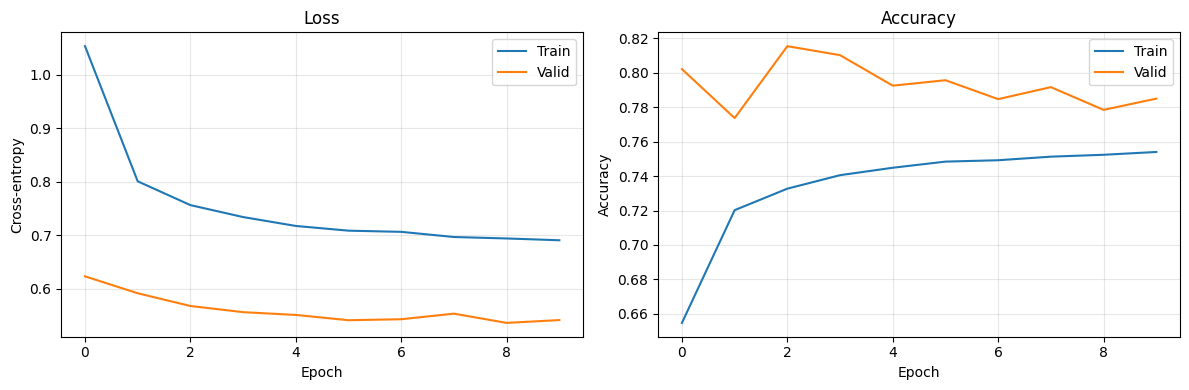

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="Train")
axes[0].plot(valid_losses, label="Valid")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label="Train")
axes[1].plot(valid_accs, label="Valid")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Test evaluation

Load the best-val-acc checkpoint back into the model, then evaluate on the held-out EMNIST test set.

In [18]:
assert best_state is not None, "Expected best_state to be populated during training"
model.load_state_dict(best_state)

y_pred, y_true = evaluate_predictions(model, device, test_loader)
test_acc = float((y_pred == y_true).mean())
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.8154


### Classification report

Showing the 10 digit classes and the 10 worst-performing non-digit classes, which is where the model's errors tend to concentrate (upper/lower case confusions, `O` vs `0`, `l` vs `1`, etc.).

In [19]:
full_report = classification_report(
    y_true, y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=LABEL_MAP,
    zero_division=0,
    output_dict=True,
)

per_class_f1 = [(i, full_report[LABEL_MAP[i]]["f1-score"]) for i in range(NUM_CLASSES)]
digit_indices = list(range(10))
non_digit_sorted = sorted(
    ((i, f1) for i, f1 in per_class_f1 if i >= 10), key=lambda t: t[1]
)
worst_non_digits = [i for i, _ in non_digit_sorted[:10]]
selected = digit_indices + worst_non_digits

print(classification_report(
    y_true, y_pred,
    labels=selected,
    target_names=[LABEL_MAP[i] for i in selected],
    zero_division=0,
    digits=4,
))
print(f"Macro F1 (all 62 classes): {full_report['macro avg']['f1-score']:.4f}")
print(f"Weighted F1              : {full_report['weighted avg']['f1-score']:.4f}")

              precision    recall  f1-score   support

           0     0.7189    0.6139    0.6622      5778
           1     0.7131    0.6322    0.6702      6330
           2     0.9844    0.8378    0.9052      5869
           3     0.9971    0.9786    0.9877      5969
           4     0.9854    0.9256    0.9546      5619
           5     0.9393    0.9185    0.9288      5190
           6     0.9845    0.9155    0.9488      5705
           7     0.9897    0.9835    0.9866      6139
           8     0.9854    0.9471    0.9659      5633
           9     0.9234    0.9560    0.9394      5686
           o     0.0645    0.3605    0.1094       466
           s     0.1442    0.2494    0.1827       437
           u     0.3713    0.1556    0.2193       482
           c     0.2838    0.3009    0.2921       432
           l     0.4561    0.2233    0.2998      2535
           f     0.3361    0.3050    0.3198       400
           m     0.3563    0.3901    0.3724       464
           y     0.5104    

### Confusion matrix

Row-normalized 62x62 confusion matrix. Log-scaled color so off-diagonal confusions (which are much smaller than the diagonal) are still visible.

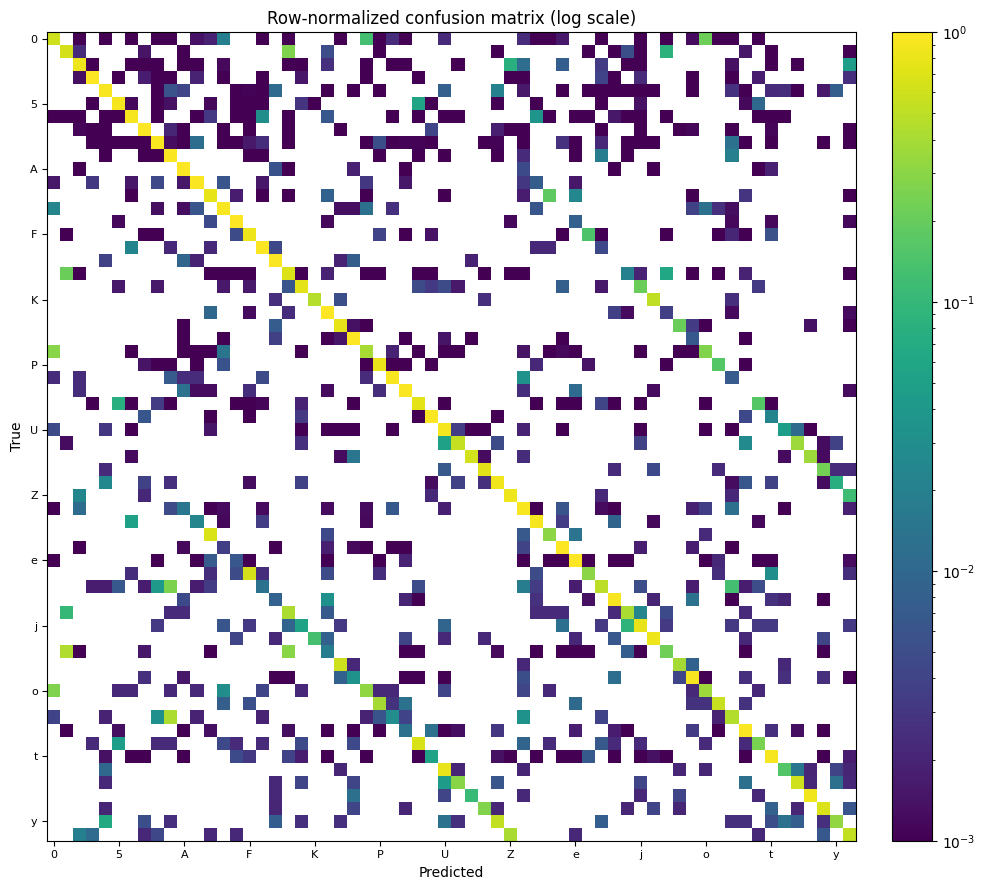

Top off-diagonal confusions (row -> col, fraction of row):
   u -> U : 0.801
   c -> C : 0.671
   s -> S : 0.650
   f -> F : 0.635
   m -> M : 0.595
   y -> Y : 0.533
   K -> k : 0.518
   l -> 1 : 0.445
   i -> I : 0.431
   q -> 9 : 0.428


In [20]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm_norm, cmap="viridis", norm=plt.matplotlib.colors.LogNorm(vmin=1e-3, vmax=1.0))
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Row-normalized confusion matrix (log scale)")
step = 5
ax.set_xticks(range(0, NUM_CLASSES, step))
ax.set_xticklabels([LABEL_MAP[i] for i in range(0, NUM_CLASSES, step)], fontsize=8)
ax.set_yticks(range(0, NUM_CLASSES, step))
ax.set_yticklabels([LABEL_MAP[i] for i in range(0, NUM_CLASSES, step)], fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

off_diag = cm_norm.copy()
np.fill_diagonal(off_diag, 0)
flat = np.argsort(off_diag.flatten())[::-1][:10]
print("Top off-diagonal confusions (row -> col, fraction of row):")
for idx in flat:
    r, c = divmod(int(idx), NUM_CLASSES)
    print(f"  {LABEL_MAP[r]:>2} -> {LABEL_MAP[c]:<2}: {off_diag[r, c]:.3f}")

### Qualitative predictions

16 random test samples. Title is `pred / true`, green when correct and red when wrong.

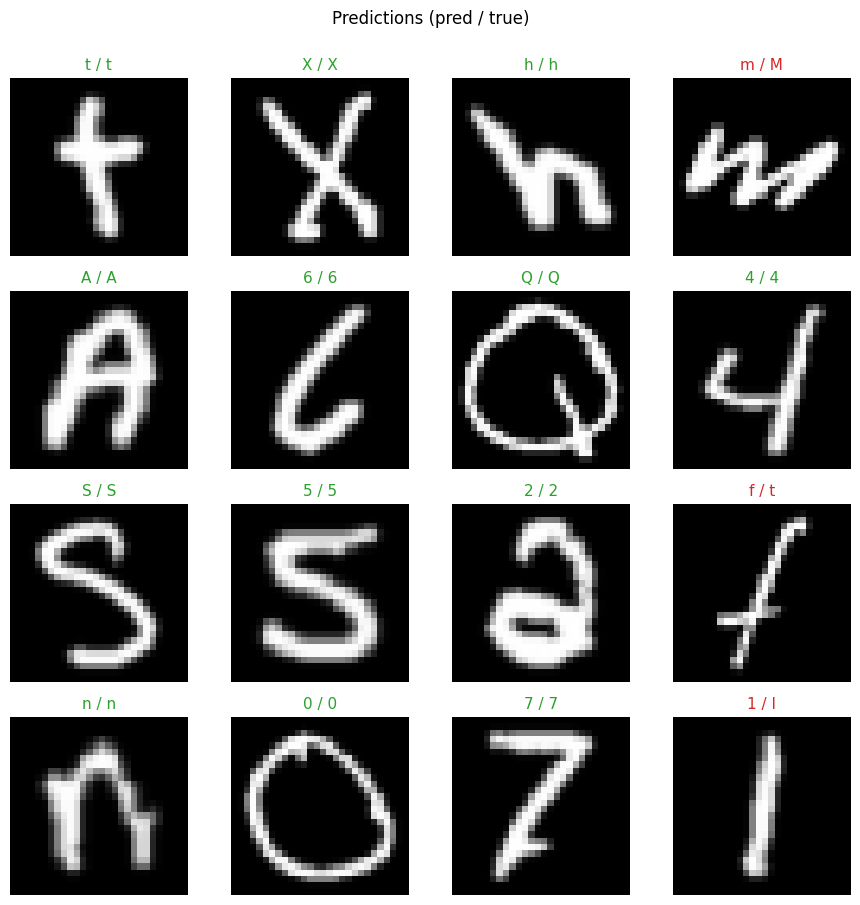

In [21]:
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(test_set), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(9, 9))
for ax, idx in zip(axes.flatten(), sample_indices):
    img_tensor, label = test_set[int(idx)]
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(device))
        pred = int(logits.argmax(dim=1).item())
    correct = pred == label
    img = img_tensor.squeeze().cpu().numpy()
    img = img * EMNIST_STD[0] + EMNIST_MEAN[0]
    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"{LABEL_MAP[pred]} / {LABEL_MAP[label]}",
        color=("tab:green" if correct else "tab:red"),
        fontsize=11,
    )
    ax.axis("off")
plt.suptitle("Predictions (pred / true)", y=1.0)
plt.tight_layout()
plt.show()

## Save weights

Persist the best `state_dict` together with the winning hyperparameters and the label map so the serving code in `../main.py` can re-instantiate `RecognitionCNN` without having to re-derive the architecture by hand.

In [22]:
weights_path = MODELS_DIR / "recognition_cnn.pt"
torch.save(
    {
        "model_state_dict": best_state,
        "best_params": best_params,
        "num_classes": NUM_CLASSES,
        "label_map": LABEL_MAP,
        "img_size": IMG_SIZE,
        "mean": EMNIST_MEAN,
        "std": EMNIST_STD,
        "val_accuracy": best_val_acc,
        "test_accuracy": test_acc,
    },
    weights_path,
)
print("Saved weights to:", weights_path)

Saved weights to: /Users/suryaguthikonda/Personal/Github/crisp/stage1_ocr/models/recognition_cnn.pt


## Conclusion

The small two-block CNN reaches solid test accuracy on EMNIST `byclass` after a short Optuna search. Most remaining errors concentrate on the known hard pairs (upper vs lower case `O`/`o`, `C`/`c`, `S`/`s`, `X`/`x`, `Z`/`z`, plus `0`/`O` and `1`/`l`/`I`), which EMNIST itself treats as distinct classes.

To plug this into the full OCR pipeline, any glyph crop produced by [../segmentation/segment_characters.py](../segmentation/segment_characters.py) must be preprocessed to match what this model saw during training:

1. Convert to grayscale, foreground on black (dark ink on light background, same polarity as the EMNIST samples we visualize above).
2. Pad to square + resize to 28x28 with binary-friendly interpolation.
3. Apply the `eval_transform` (which already covers the EMNIST orientation flip and the mean/std normalization).

Ideas to push accuracy further:

- Train longer and/or widen the Optuna budget.
- Add batch normalization between conv layers and/or a learning-rate scheduler (`CosineAnnealingLR`).
- Augment more aggressively (elastic distortions, cutout).
- Consider `balanced` EMNIST instead of `byclass` if merging hard case pairs (`C/c`, `O/o`, ...) is acceptable - accuracy typically jumps several points.